In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Microglia"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 81472 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch'
    var: 'gene_symbol'

In [4]:
adata.var.set_index("gene_symbol", inplace=True)
adata.var.index = adata.var.index.astype(str)
adata.var_names_make_unique()

**Differential Expression**

In [5]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)  # Select highly variable genes
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15)
adata.obsm["X_umap"] = adata.obs[["x", "y"]].to_numpy()

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Clustering the data
resolution_list = [0.2, 0.3, 0.4, 0.5]
for res in resolution_list:
    sc.tl.leiden(
        adata,
        resolution=res,
        flavor="igraph",
        n_iterations=2,
        key_added=f"leiden_res_{res:4.2f}"
        )

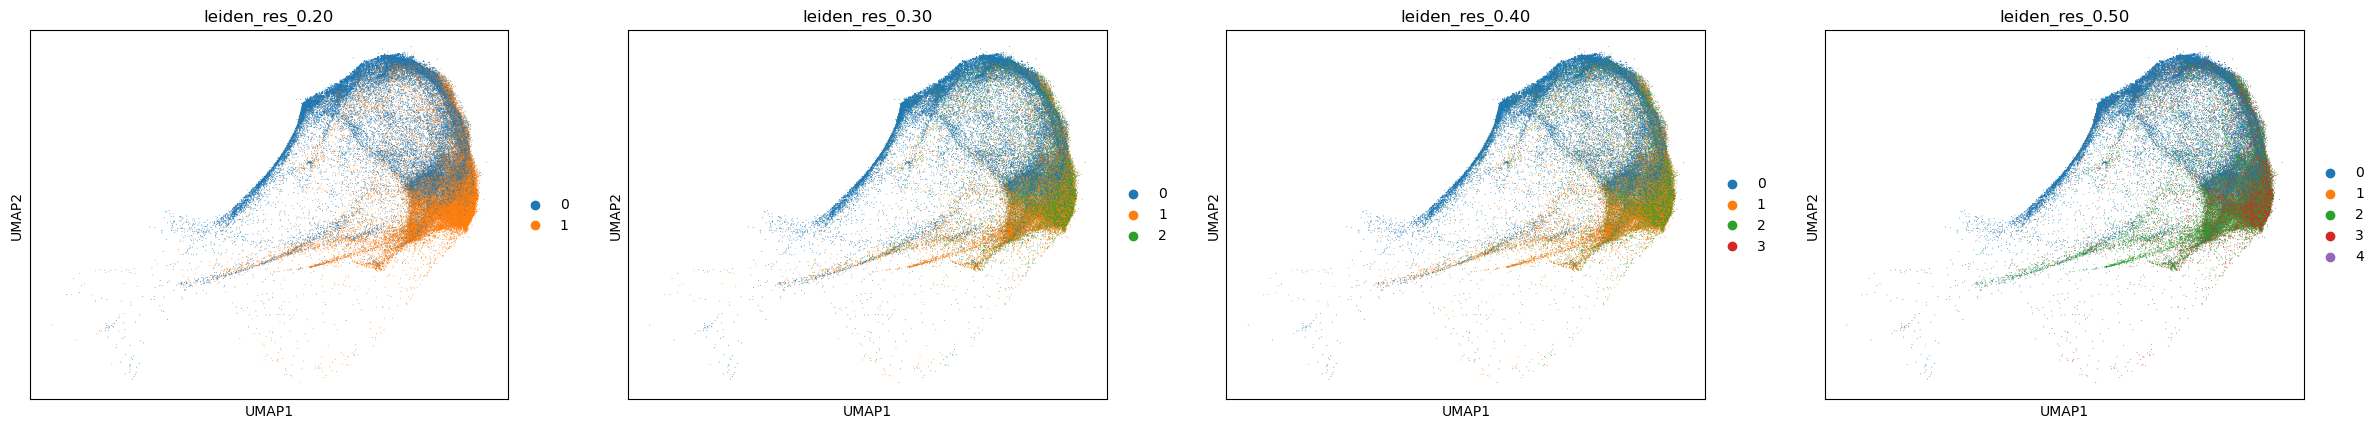

In [7]:
# Plotting the UMAPs
sc.pl.umap(adata, color=[f"leiden_res_{res:4.2f}" for res in resolution_list])

In [9]:
# Perform differential expression analysis
for res in resolution_list:
    sc.tl.rank_genes_groups(
        adata,
        groupby=f"leiden_res_{res:4.2f}",
        method="wilcoxon",
        key_added=f"rank_genes_res_{res:4.2f}",
        mask_var=adata.var["highly_variable"].values,
        use_raw=False
    )

In [11]:
# Saving the DEG dataframes
for res in resolution_list:
    leiden_key = f"leiden_res_{res:4.2f}"

    # Extract the differential expression results
    deg_results = pd.DataFrame({
        group: pd.DataFrame(adata.uns[f"rank_genes_res_{res:4.2f}"]["names"])[group]
        for group in adata.uns[f"rank_genes_res_{res:4.2f}"]["names"].dtype.names
    })

    # Save the dataframe to a CSV file
    output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{leiden_key}.csv"
    deg_results.to_csv(output_path, index=False)

    print(f"Differentially expressed genes saved to {output_path}")

Differentially expressed genes saved to /data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/DEG/WMB-10Xv3-Microglia-DEG-leiden_res_0.20.csv
Differentially expressed genes saved to /data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/DEG/WMB-10Xv3-Microglia-DEG-leiden_res_0.30.csv
Differentially expressed genes saved to /data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/DEG/WMB-10Xv3-Microglia-DEG-leiden_res_0.40.csv
Differentially expressed genes saved to /data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/DEG/WMB-10Xv3-Microglia-DEG-leiden_res_0.50.csv


In [13]:
# Saving processed AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
save_path = base_path / f"processed/WMB-10Xv3-{select_region}-raw-wmeta-DEG.h5ad"
sc.write(save_path, adata)

## Identifying number of clusters

### Number of cells in each cluster

In [44]:
# Show the number of cells in each identified cluster
for res in resolution_list:
    leiden_key = f"leiden_res_{res:4.2f}"
    cluster_counts = adata.obs[leiden_key].value_counts().sort_index()
    print(cluster_counts)

leiden_res_0.20
0    40528
1    40944
Name: count, dtype: int64
leiden_res_0.30
0    37995
1    26561
2    16916
Name: count, dtype: int64
leiden_res_0.40
0    36575
1    27473
2    17294
3      130
Name: count, dtype: int64
leiden_res_0.50
0    34784
1      764
2    28523
3    17232
4      169
Name: count, dtype: int64


### Threshold: LogFC and FDR

In [46]:
def filter_degs_all_classes(adata, rank_genes_key, logfc_thresh=1.0, fdr_thresh=0.05, absolute_logfc=True):
    """
    Return a dictionary of DataFrames of DEGs for all classes passing logFC and FDR thresholds.
    Args:
        adata: AnnData object with rank_genes_groups results.
        logfc_thresh: Minimum absolute log2 fold change.
        fdr_thresh: Maximum adjusted p-value (FDR).
    Returns:
        Dictionary with class names as keys and DataFrames as values.
    """
    rg = adata.uns[rank_genes_key]
    classes = rg["names"].dtype.names
    degs_dict = {}
    for cls in classes:
        genes = rg["names"][cls]
        logfc = rg["logfoldchanges"][cls]
        pvals_adj = rg["pvals_adj"][cls]
        df = pd.DataFrame({
            "gene": genes,
            "logFC": logfc,
            "pval_adj": pvals_adj
        })
        if absolute_logfc:
            mask = (df["pval_adj"] < fdr_thresh) & (abs(df["logFC"]) > logfc_thresh)
        else:
            mask = (df["pval_adj"] < fdr_thresh) & (df["logFC"] > logfc_thresh)
        degs_dict[cls] = df[mask].reset_index(drop=True)
    return degs_dict

In [51]:
for res in resolution_list:
    print(f"\nProcessing resolution: {res}")
    rank_genes_key = f"rank_genes_res_{res:4.2f}"
    sig_DEGs_dict = filter_degs_all_classes(adata, rank_genes_key=rank_genes_key, logfc_thresh=0.5, fdr_thresh=0.01, absolute_logfc=False)
    for key, df in sig_DEGs_dict.items():
        print(f"Cluster {key} at resolution {res}: {len(df)} significant DEGs")


Processing resolution: 0.2
Cluster 0 at resolution 0.2: 304 significant DEGs
Cluster 1 at resolution 0.2: 120 significant DEGs

Processing resolution: 0.3
Cluster 0 at resolution 0.3: 306 significant DEGs
Cluster 1 at resolution 0.3: 68 significant DEGs
Cluster 2 at resolution 0.3: 30 significant DEGs

Processing resolution: 0.4
Cluster 0 at resolution 0.4: 307 significant DEGs
Cluster 1 at resolution 0.4: 63 significant DEGs
Cluster 2 at resolution 0.4: 27 significant DEGs
Cluster 3 at resolution 0.4: 97 significant DEGs

Processing resolution: 0.5
Cluster 0 at resolution 0.5: 312 significant DEGs
Cluster 1 at resolution 0.5: 117 significant DEGs
Cluster 2 at resolution 0.5: 56 significant DEGs
Cluster 3 at resolution 0.5: 27 significant DEGs
Cluster 4 at resolution 0.5: 131 significant DEGs


### Heatmap: scaled mean expression

In [33]:
def plot_cluster_marker_heatmap(
    adata,
    cluster_key,
    n_genes=10,
    scale=True,
    figsize=(10, 8),
    cmap="vlag",
    save_path=None,
    rank_genes_key=None
):
    """
    Plot a heatmap of scaled mean expression of top marker genes for each cluster.

    Args:
        adata: AnnData object.
        cluster_key: str, column in adata.obs for cluster labels.
        n_genes: int, number of top marker genes per cluster.
        scale: bool, whether to z-score scale genes across clusters.
        figsize: tuple, figure size.
        cmap: str, colormap.
        save_path: str or None, path to save figure.
        rank_genes_key: str or None, key in adata.uns for ranked genes (e.g. 'rank_genes_res_0.20').
    """
    if rank_genes_key is None:
        raise ValueError("Please provide rank_genes_key (e.g. 'rank_genes_res_0.20').")

    # Get top marker genes from adata.uns
    rank_genes = adata.uns[rank_genes_key]["names"]
    clusters = rank_genes.dtype.names
    top_genes = []
    for cl in clusters:
        top_genes.extend(rank_genes[cl][:n_genes])
    top_genes = list(dict.fromkeys(top_genes))  # remove duplicates, preserve order

    # Compute mean expression per cluster for these genes
    cluster_labels = adata.obs[cluster_key].unique()
    cluster_labels = sorted(cluster_labels, key=lambda x: str(x))
    expr = adata[:, top_genes].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    expr_df = pd.DataFrame(expr, index=adata.obs[cluster_key], columns=top_genes)
    mean_expr = expr_df.groupby(level=0, observed=False).mean().reindex(cluster_labels)

    # Optionally scale (z-score) genes across clusters
    if scale:
        mean_expr = (mean_expr - mean_expr.mean(axis=0)) / mean_expr.std(axis=0)
        vmin, vmax = -2, 2
    else:
        vmin = vmax = None

    # Plot clustered heatmap
    g = sns.clustermap(
        mean_expr.T,
        figsize=figsize,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        row_cluster=True,
        col_cluster=True,
        xticklabels=True,
        yticklabels=False,
        cbar_kws={"label": "Scaled mean expression" if scale else "Mean expression"}
    )
    g.ax_heatmap.set_xlabel("Cluster")
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(),
        rotation=30,
        ha='right'
    )
    g.ax_heatmap.set_ylabel("Gene")
    plt.title("")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

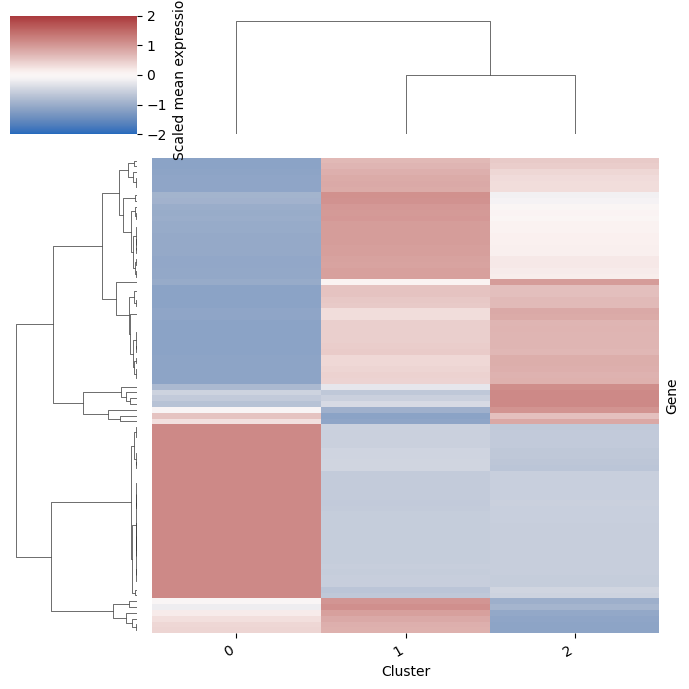

In [41]:
plot_cluster_marker_heatmap(
    adata,
    cluster_key = "leiden_res_0.30",
    n_genes=30,
    scale=True,
    figsize=(7, 7),
    cmap="vlag",
    save_path=None,
    rank_genes_key= "rank_genes_res_0.30"
)

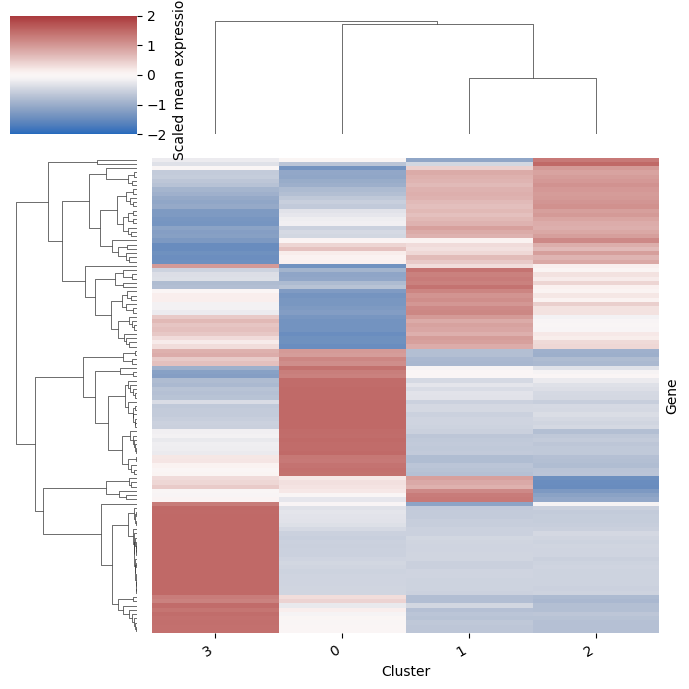

In [42]:
plot_cluster_marker_heatmap(
    adata,
    cluster_key = "leiden_res_0.40",
    n_genes=30,
    scale=True,
    figsize=(7, 7),
    cmap="vlag",
    save_path=None,
    rank_genes_key= "rank_genes_res_0.40"
)

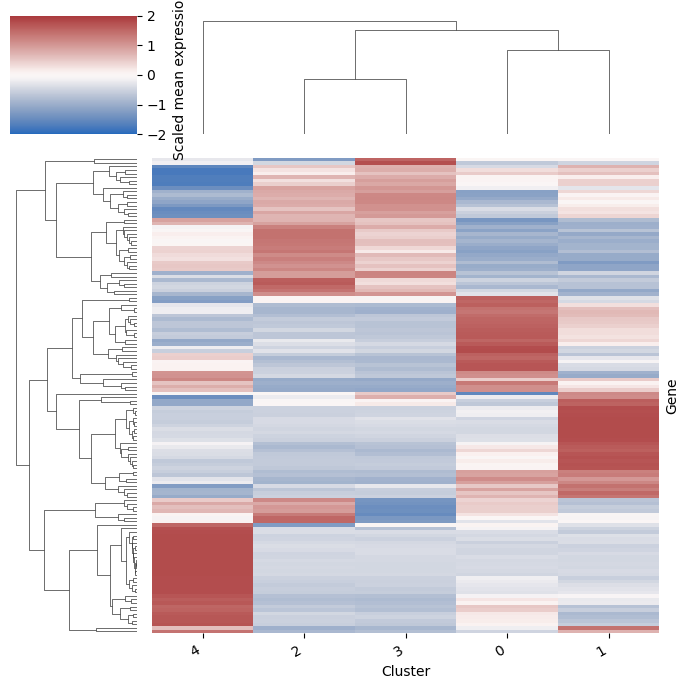

In [43]:
plot_cluster_marker_heatmap(
    adata,
    cluster_key = "leiden_res_0.50",
    n_genes=30,
    scale=True,
    figsize=(7, 7),
    cmap="vlag",
    save_path=None,
    rank_genes_key= "rank_genes_res_0.50"
)